In [1]:
from data_utils.ABC_dataset import ABCDataset, get_item
import numpy as np
import matplotlib.pyplot as plt
import utils.mesh_tools as mt
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm

In [2]:
device='cuda'

In [3]:
src_dir = "../data/groundtruth/gt_NMC/"
with open('data_utils/abc_watertight_train.txt', 'r') as f:
    train_set_names = [e[:-1] for e in f.readlines()]

In [4]:
# TODO: move some of these functions to ABC_dataset
def vdb_marching_cubes(out: fvnn.VDBTensor):
    '''computes marching cubes for a VDBTensor'''
    nv, nf, _ = out.grid.marching_cubes(out.data)
    return nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()

def fetch_numpy_values(grid: fvdb.GridBatch, arr: np.array, size:int):
    '''fetches values from a numpy array based on the ijk indices in the grid'''
    ijk = grid.ijk.jdata.cpu().detach().numpy()+(size-1)//2
    values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
    return torch.tensor(values, dtype=torch.float32, device=grid.device)
    
def sdf_to_vdb(sdf_grid, large_sdf_grid, mask, size=33):
    '''takes SDF pair grids and a mask, returns small and large VDBTensors. SDF values scaled by size'''
    ijk_mesh_grid = mt.mesh_grid(size)
    ijk_mesh_grid = ijk_mesh_grid.reshape(size, size, size, 3)
    ijk = torch.tensor(ijk_mesh_grid[mask], dtype=torch.int, device=device)-(size-1)//2
    grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk), voxel_sizes=(1/(size-1)), origins=torch.tensor([0, 0, 0], device=device))
    sdf_values = fetch_numpy_values(grid, sdf_grid, size)
    small_vdb = fvnn.VDBTensor(grid, grid.jagged_like((size-1)*sdf_values[:, None]))
    
    # extract large sdf grid
    big_vdb_grid = custom_subdivide_grid(small_vdb.grid)
    sdf_values = fetch_numpy_values(big_vdb_grid, large_sdf_grid, 2*size-1)
    large_vdb = fvnn.VDBTensor(big_vdb_grid, big_vdb_grid.jagged_like((size-1)*sdf_values[:, None]))

    return small_vdb, large_vdb

def custom_subdivide_grid(grid: fvdb.GridBatch):
    '''custom subdivision of a grid to create a finer grid:
        [0,    1,    2] -->
        [0, 1, 2, 3, 4]'''
    ijk = grid.ijk.jdata
    m3g = torch.tensor(mt.mesh_grid(3),device=device)-1
    new_ijk = (2*ijk[:, None, :]+ m3g[None, :, :]).view(-1, 3)
    return fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(new_ijk), origins=grid.origins, voxel_sizes=grid.voxel_sizes/2)

In [5]:
def NDCnormalize(vertices, return_scale=False):
    """normalization in half unit ball"""
    vM = vertices.max(0)
    vm = vertices.min(0)
    scale = np.sqrt(((vM - vm) ** 2).sum(-1))
    mean = (vM + vm) / 2.0
    nverts = (vertices - mean) / scale
    if return_scale:
        return nverts, mean, scale
    return nverts

In [ ]:
### load whole dataset
# load_dataset = ABCDataset(src_dir, train_set_names[:50])

# ## load single shape
# small_sdf, large_sdf = get_item(src_dir, train_set_names[0])
example_mesh = '../data/bunny.obj'
grid_n = 33

v, f = igl.read_triangle_mesh(example_mesh)
v = 2*NDCnormalize(v)
points = mt.mesh_grid(grid_n, True)
# mt.plotSlice(small_sdf, 0.1)
sdf = igl.signed_distance(points, v, f)[0].reshape(grid_n, grid_n, grid_n)
mt.plotSlice(sdf, 0.1)

100%|██████████| 50/50 [00:00<00:00, 1279.56it/s]


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../data/groundtruth/gt_NMC/00000020.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [7]:
small_sdf = sdf

In [8]:
def make_mask_close(sdf_input, grid_n):
    # dense grid--> sparse grid
    mask = np.abs(sdf_input) < (1/grid_n*np.sqrt(3))
    return mask


mask = make_mask_close(small_sdf, 33)
big_mask = mask.repeat(2, 0).repeat(2, 1).repeat(2, 2)
large_sdf = small_sdf.repeat(2, 0).repeat(2, 1).repeat(2, 2)
mt.plotSlice(small_sdf*mask, 0.1)
# mt.plotSlice(large_sdf*big_mask, 0.1)

interactive(children=(IntSlider(value=16, description='s', max=32), Output()), _dom_classes=('widget-interact'…

<function utils.mesh_tools.plotSlice.<locals>.<lambda>(s)>

In [9]:
### GET VDB tensor
small_vdb, large_vdb = sdf_to_vdb(small_sdf, large_sdf.squeeze(), mask)

In [10]:
# sanity check:
indices = large_vdb.grid.ijk_to_index(small_vdb.ijk.jdata*2)
(large_vdb.data[indices].jdata-small_vdb.jdata).max()

tensor(0., device='cuda:0')

In [11]:
mt.export_obj(*vdb_marching_cubes(small_vdb), '32_vdb.obj')
mt.export_obj(*vdb_marching_cubes(large_vdb), '64_vdb.obj')

In [12]:

def positional_encoding(small_vdb, dim):
    '''helps the learning'''
    feat = small_vdb.jdata
    half_dim = dim // 2
    emb = torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=feat.device)
    emb = 2**emb * torch.pi
    emb = feat.float() * emb[None, :]
    new_feat = torch.cat([feat, emb.sin(), emb.cos()], dim=-1)
    return fvnn.VDBTensor(small_vdb.grid, small_vdb.grid.jagged_like(new_feat))
    



In [13]:

class CNN_vanilla(nn.Module):
    def __init__(self, in_channels=3, features=32, out_channels=1, dropout=0.05):
        super(CNN_vanilla, self).__init__()
        print('TODO:  \n - check that the transposed conv is correct \n - add/remove layers \n - add MaxPool to be invariant to sparse grid activations?')
        self.activation = fvnn.SiLU(inplace=True)
        self.encoder = nn.Sequential(
            fvnn.SparseConv3d(in_channels, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation,

            fvnn.SparseConv3d(features, features, kernel_size=3, stride=1),
            fvnn.Dropout(dropout),
            self.activation
        )
        
        self.decoder = nn.Sequential(
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=1, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, features, kernel_size=1, stride=1),
            fvnn.Dropout(dropout),
            self.activation,
            fvnn.SparseConv3d(features, out_channels, kernel_size=1, stride=1)
        )

        self.t_conv = fvnn.SparseConv3d(
            features, features, kernel_size=3, stride=2, transposed=True) #TODO check that this is correct

    def forward(self, x, out_grid):
        enc = self.encoder(x)
        x = self.t_conv(enc, out_grid=out_grid) 
        return self.decoder(x)

pos_enc_dim = 10
input_vdb = positional_encoding(small_vdb, 10)
M = CNN_vanilla(in_channels=pos_enc_dim+1, features=128, out_channels=1, dropout=0.00).to(device)
# M(small_vdb, large_vdb.grid)
M.train()
# small_vdb.data.jdata.shape

optimizer = torch.optim.Adam(M.parameters(), lr=1e-4)
L = []
def train_step(model, optimizer, input_vdb, large_vdb):
    optimizer.zero_grad()
    out = model(input_vdb, large_vdb.grid)
    loss = nn.functional.mse_loss(out.jdata, large_vdb.data.jdata)
    loss.backward()
    optimizer.step()
    return loss.item()

TODO:  
 - check that the transposed conv is correct 
 - add/remove layers 
 - add MaxPool to be invariant to sparse grid activations?


Model like -> downsample cnn -> upsample cnn Transpose -> invariant cnn
TODO:
- Yes it is correct
- 
- if you the small shift the input maxpool is translation invariant 
for example
[0,0,0,1,0]->1
[0,0,0,0,1]->1
small translation does not change the value

In [14]:
for i in tqdm(range(2000)):
    L.append(train_step(M, optimizer, input_vdb, large_vdb))

100%|██████████| 2000/2000 [00:26<00:00, 74.80it/s]


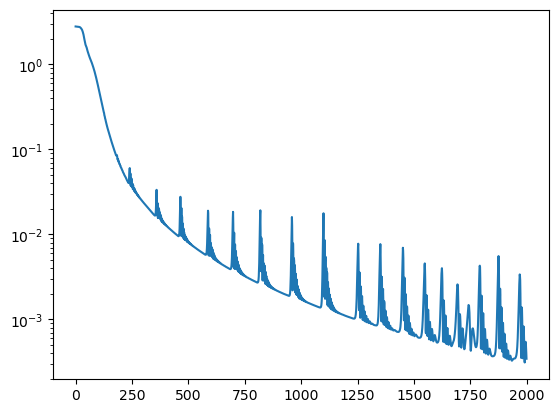

In [15]:
plt.plot(L)
plt.yscale('log')

In [16]:
large_vdb.jdata

tensor([[4.1581],
        [2.5753],
        [4.6798],
        ...,
        [1.4459],
        [1.6604],
        [1.6604]], device='cuda:0')

In [17]:
out_vdb = M(input_vdb, large_vdb.grid)
out_vdb.jdata

tensor([[4.1325],
        [2.6182],
        [4.6977],
        ...,
        [1.4487],
        [1.6647],
        [1.6641]], device='cuda:0', grad_fn=<AddBackward0>)

In [18]:
mt.export_obj(*vdb_marching_cubes(out_vdb), '64_pro.obj')

In [22]:
# visualize obj files
v, f = igl.read_triangle_mesh('64_vdb.obj')
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0076295…

In [23]:
v, f = igl.read_triangle_mesh('../data/bunny.obj')
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.000117…